# 02 — Regional Sales Performance
Compare revenue, profit, and order volume across the four sales regions.

## Setup — Spark Session & Load HDFS Tables

In [1]:
import os, sys

os.environ["JAVA_HOME"]             = "/usr/local/java"
os.environ["SPARK_HOME"]            = "/usr/local/spark"
os.environ["HADOOP_CONF_DIR"]       = "/usr/local/hadoop/etc/hadoop"
os.environ["PYSPARK_PYTHON"]        = sys.executable
os.environ["PYSPARK_DRIVER_PYTHON"] = sys.executable

import findspark
findspark.init()

from pyspark.sql import SparkSession

spark = SparkSession.getActiveSession()
if spark is None:
    spark = (SparkSession.builder
        .appName("02 — Regional Sales Performance")
        .master("local[*]")
        .config("spark.sql.shuffle.partitions", "4")
        .getOrCreate())

spark.sparkContext.setLogLevel("WARN")

HDFS_BASE = "hdfs:///data"

def load_csv(name, renames):
    df = (spark.read
          .option("header", "true")
          .option("inferSchema", "true")
          .csv(f"{HDFS_BASE}/{name}.csv"))
    for old, new in renames.items():
        df = df.withColumnRenamed(old, new)
    df.createOrReplaceTempView(name)
    return df

load_csv("customers",   {"Customer ID":"customer_id","Customer Name":"customer_name","Segment":"segment"})
load_csv("orders",      {"Order ID":"order_id","Order Date":"order_date","Ship Date":"ship_date",
                          "Ship Mode":"ship_mode","Customer ID":"customer_id","Postal Code":"postal_code"})
load_csv("order_items", {"Row ID":"row_id","Order ID":"order_id","Product ID":"product_id",
                          "Sales":"sales","Quantity":"quantity","Discount":"discount","Profit":"profit"})
load_csv("products",    {"Product ID":"product_id","Product Name":"product_name",
                          "Category":"category","Sub-Category":"sub_category"})
load_csv("locations",   {"Postal Code":"postal_code","City":"city","State":"state",
                          "Country":"country","Region":"region"})

import matplotlib.pyplot as plt
%matplotlib inline
import matplotlib.ticker as mticker
import pandas as pd
import numpy as np

plt.rcParams.update({"figure.dpi": 120, "axes.spines.top": False, "axes.spines.right": False})
print("Ready.")


Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/04/27 17:37:43 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable
26/04/27 17:37:43 WARN Utils: Service 'SparkUI' could not bind on port 4040. Attempting port 4041.


Ready.


## Query

In [2]:
df = spark.sql('''
    SELECT
        l.region,
        ROUND(SUM(oi.sales),  2)          AS total_sales,
        ROUND(SUM(oi.profit), 2)          AS total_profit,
        COUNT(DISTINCT o.order_id)        AS total_orders,
        ROUND(AVG(oi.sales), 2)           AS avg_item_value
    FROM orders o
    JOIN order_items oi ON o.order_id    = oi.order_id
    JOIN locations   l  ON o.postal_code = l.postal_code
    GROUP BY l.region
    ORDER BY total_sales DESC
''').toPandas()
print(df)

    region  total_sales  total_profit  total_orders  avg_item_value
0     West    733103.95     109879.80          1611          226.13
1     East    678781.24      91522.78          1401          238.34
2  Central    501239.89      39706.36          1175          215.77
3    South    391721.90      46749.43           822          241.80


## Visualisation

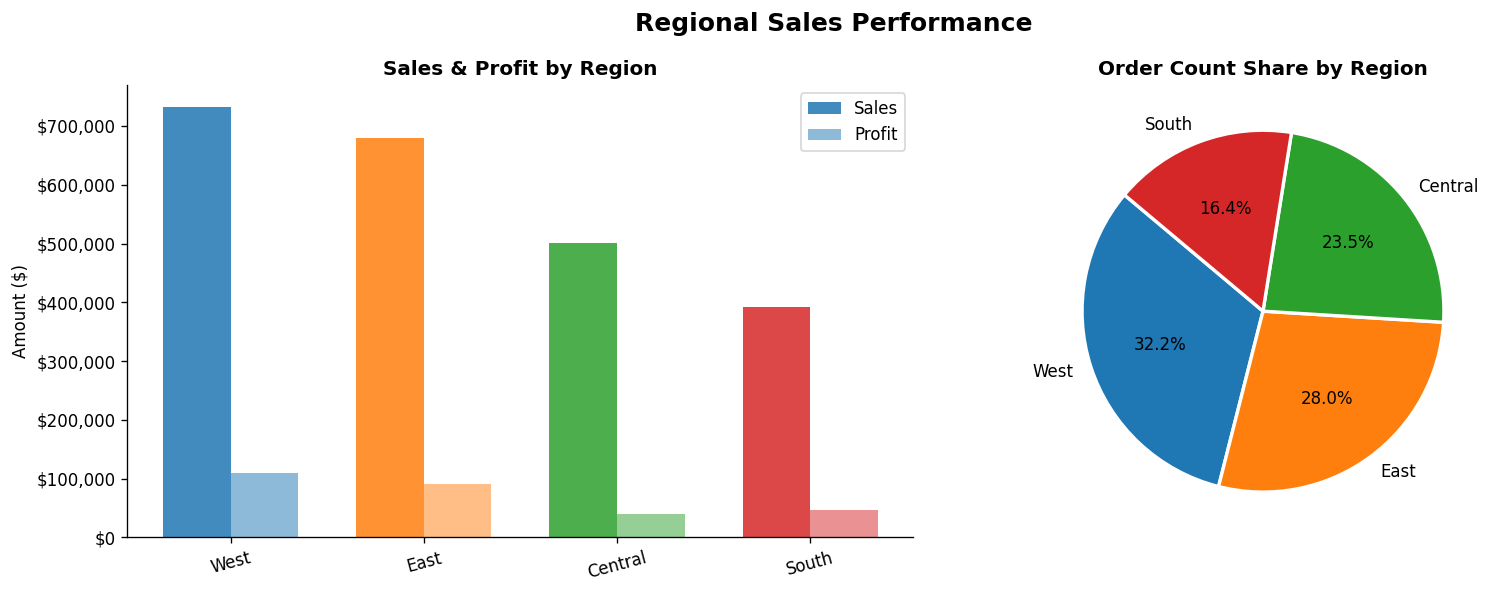

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
colors = ["#1f77b4","#ff7f0e","#2ca02c","#d62728"]
w = 0.35; x = range(len(df))

axes[0].bar([i - w/2 for i in x], df["total_sales"],  w, label="Sales",  color=colors, alpha=0.85)
axes[0].bar([i + w/2 for i in x], df["total_profit"], w, label="Profit", color=colors, alpha=0.5)
axes[0].set_xticks(list(x)); axes[0].set_xticklabels(df["region"], rotation=15)
axes[0].set_title("Sales & Profit by Region", fontweight="bold"); axes[0].set_ylabel("Amount ($)")
axes[0].legend(); axes[0].yaxis.set_major_formatter(mticker.FuncFormatter(lambda v,_: f"${v:,.0f}"))

axes[1].pie(df["total_orders"], labels=df["region"], autopct="%1.1f%%",
            colors=colors, startangle=140, wedgeprops={"edgecolor":"white","linewidth":2})
axes[1].set_title("Order Count Share by Region", fontweight="bold")

plt.suptitle("Regional Sales Performance", fontsize=15, fontweight="bold")
plt.tight_layout(); plt.show()